# Thông tin kết nối google drive và extract tập dữ liệu

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Extract file rar

In [2]:
# !apt-get install unrar
# new_rar_path = '/content/drive/MyDrive/CS321_CV/HoaVietNam.rar'
# !unrar x $new_rar_path /content/drive/MyDrive/CS321_CV/

# 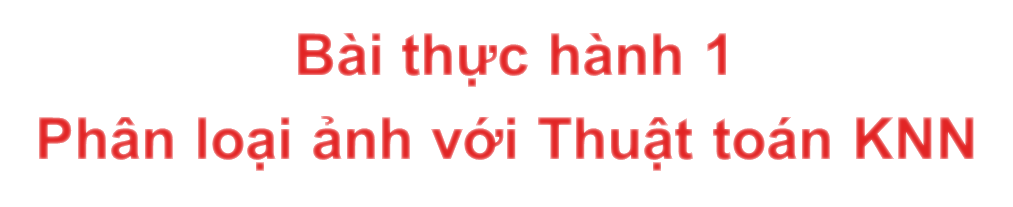

# 1. Mô tả

Cho trước 1 tập dữ liệu HoaVietNam chứa 05 loài hoa:
- Cuc: Tên loài hoa Cúc
- Dao: Tên loài hoa Đào
- Lan: Tên loài hoa Phong lan
- Mai: Tên loài hoa Mai
- Tho: Tên loài hoa Vạn thọ

Được tổ chức như sau:
- train: chứa 05 thư mục tương vơi 05 loài hoa, mỗi thư mục có 30 ảnh *.jpg
- test: chứa 05 thư mục tương vơi 05 loài hoa, mỗi thư mục có 10 ảnh *.jpg


# 2. Yêu cầu

- Mỗi ảnh sẽ được biểu diễn bằng vector đặc trưng dựa trên Histogram cho ảnh màu.
- Hãy áp dụng Bộ phân lớp KNeighborsClassifier với giá trị k=7 ( Từ thư viện: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html ) để xác định giá trị cho Độ chính xác cao nhất của hai tham số sau:

•	weights: {‘uniform’, ‘distance’}

•	metric: {

    •	braycurtis: Compute the Bray-Curtis distance between two 1-D arrays.

    •	canberra: Compute the Canberra distance between two 1-D arrays.

    •	correlation: Compute the correlation distance between two 1-D arrays.

    •	cosine: Compute the Cosine distance between 1-D arrays.

    •	euclidean: Computes the Euclidean distance between two 1-D arrays.

    •	minkowski: Compute the Minkowski distance between two 1-D arrays.
}



# Bài làm

## 1) Khai báo thư viên

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

## 2) Đường dẫn tập dữ liệu

In [5]:
root_dir = '/content/drive/MyDrive/CS231_CV/Data/'
train_dir = os.path.join(root_dir, 'HoaVietNam', 'train')
test_dir = os.path.join(root_dir, 'HoaVietNam', 'test')

## 3) Hàm trích xuất đặc trưng Histogram với kênh màu RGB

In [6]:
def extract_color_histogram_RGB(img_path, bins=256):
    # Đọc ảnh & chuyển từ BGR -> RGB
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Tính histogram và chuẩn hóa thành feature vector
    feature_vector = []

    # Duyệt qua từng kênh màu R, G, B:
    for i in range(3):
        hist = cv2.calcHist([img], [i], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten() # Chuẩn hóa và làm phẳng
        feature_vector.extend(hist)

    # Chuẩn hóa và làm phẳng
    feature_vector = np.array(feature_vector)
    feature_vector = cv2.normalize(feature_vector, feature_vector).flatten()

    return feature_vector # Kích thước: 256 * 3 = 768

## 4) Hàm lấy đặc trưng và nhãn kết hợp với hàm con trỏ trích xuất đặc trưng

In [7]:
def load_features_and_labels(root_dir, extract_feature_funct):
    images = []
    labels = []

    # Lấy danh sách folder con  và sắp xếp
    class_names = sorted(os.listdir(root_dir))

    for class_name in class_names:
        class_name_dir_path = os.path.join(root_dir, class_name)

        if os.path.isdir(class_name_dir_path):
            for img_file in os.listdir(class_name_dir_path): # Duyệt qua từng tệp trong thư mục
                img_path = os.path.join(class_name_dir_path, img_file)

                if img_file.endswith('.jpg'):
                    feature = extract_feature_funct(img_path)

                    if feature is not None:
                        images.append(feature)
                        labels.append(class_name)

    return np.array(images), np.array(labels)

## 5) Load dataset với trích xuất đặc trưng histogram và kênh mày RGB

In [8]:
X_train_rgb, y_train_rgb = load_features_and_labels(train_dir, extract_color_histogram_RGB)
X_test_rgb, y_test_rgb = load_features_and_labels(test_dir, extract_color_histogram_RGB)

In [9]:
print('X_train_rgb:', X_train_rgb.shape)
print('y_train_rgb:', y_train_rgb.shape)
print('X_test_rgb:', X_test_rgb.shape)
print('y_test_rgb:', y_test_rgb.shape)

X_train_rgb: (150, 768)
y_train_rgb: (150,)
X_test_rgb: (50, 768)
y_test_rgb: (50,)


## 6) Encode tập dữ liệu với trích xuất đặc trưng histogram

In [10]:
# Mã hóa nhãn
le = LabelEncoder()
le.fit(y_train_rgb)
y_train_rgb_encoded = le.transform(y_train_rgb)
y_test_rgb_encoded = le.transform(y_test_rgb)


In [11]:
print(y_train_rgb_encoded.shape)
print(y_test_rgb_encoded.shape)


(150,)
(50,)


## 7) Train và test

In [12]:
def train_knn(X_train, y_train, X_test, y_test, k , metric, weight):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred

In [13]:
def test(metrics, weights_options, X_train, y_train, X_test, y_test, best_accuracy=0, best_params={}, k=7):
    for metric in metrics:
        for weight in weights_options:
            accuracy, _ = train_knn(X_train, y_train, X_test, y_test, k, metric, weight)
            print(f"Accuracy with weight[{weight:>4}], metric[{metric}] = {accuracy:.2f}")

            if accuracy > best_accuracy:
                best_params = {'metric': metric, 'weight': weight}
                best_accuracy = accuracy

    return best_accuracy, best_params

## 8) Siêu tham số

In [14]:
# Khởi tạo K
k = 7

# Dánh sách các tham số để test
metrics = ['braycurtis', 'canberra', 'correlation', 'cosine', 'euclidean', 'minkowski']
weights_options = ['uniform', 'distance']

best_params = {}
best_accuracy = 0

## 9) Độ chính xác tốt nhất và tham số tối ưu khi trích xuất đặc trưng histogram với kênh màu RGB

In [15]:
best_accuracy_rgb, best_params_rgb = test(metrics, weights_options, X_train_rgb, y_train_rgb_encoded, X_test_rgb, y_test_rgb_encoded)


Accuracy with weight[uniform], metric[braycurtis] = 0.74
Accuracy with weight[distance], metric[braycurtis] = 0.78
Accuracy with weight[uniform], metric[canberra] = 0.72
Accuracy with weight[distance], metric[canberra] = 0.76
Accuracy with weight[uniform], metric[correlation] = 0.70
Accuracy with weight[distance], metric[correlation] = 0.68
Accuracy with weight[uniform], metric[cosine] = 0.74
Accuracy with weight[distance], metric[cosine] = 0.76
Accuracy with weight[uniform], metric[euclidean] = 0.74
Accuracy with weight[distance], metric[euclidean] = 0.76
Accuracy with weight[uniform], metric[minkowski] = 0.74
Accuracy with weight[distance], metric[minkowski] = 0.76


## 10) In kết quả tốt nhất với trích xuất đặc trưng histogram với kênh màu RGB

In [16]:
print(f"Best accuracy from histogram feature extraction with rgb color: {best_accuracy_rgb:.2f}")
print(f"Best parameters from histogram feature extraction with rgb color: {best_params_rgb}")


Best accuracy from histogram feature extraction with rgb color: 0.78
Best parameters from histogram feature extraction with rgb color: {'metric': 'braycurtis', 'weight': 'distance'}
